In [2]:

from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS


from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

load_dotenv()

/tmp/ipykernel_8762/3204149376.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
/home/jiggra/Self_RAG/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [116]:
# -----------------------------
# 2) LLM
# -----------------------------
load_dotenv()
llmm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
)
model1 = ChatHuggingFace(llm=llmm)

model2 = ChatGroq(
    model="llama-3.3-70b-versatile",
)
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0,
)
model = model2
embeddings = HuggingFaceEmbeddings(model="BAAI/bge-small-en-v1.5")
embedding_size = len(embeddings.embed_query("Hello"))


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2713.59it/s]


In [4]:
client = QdrantClient(
    path="./qdrant_db"
)



In [5]:
from qdrant_client.models import VectorParams, Distance

client.create_collection(
    collection_name="self_rag",
    vectors_config=VectorParams(
        size=embedding_size,
        distance=Distance.COSINE,
    ),
)

ValueError: Collection self_rag already exists

In [6]:
vector_store = QdrantVectorStore(
    client=client,
    collection_name="self_rag",
    embedding=embeddings,
)

In [7]:
book1 = "/home/jiggra/Self_RAG/documents/Company_Policies.pdf"
book2 = "/home/jiggra/Self_RAG/documents/Company_Profile.pdf"
book3 = "/home/jiggra/Self_RAG/documents/Product_and_Pricing.pdf"

docs = (
    PyPDFLoader(book1).load()
    +
    PyPDFLoader(book2).load()
    +
    PyPDFLoader(book3).load()
)

In [8]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600,chunk_overlap=150).split_documents(documents=docs)

In [9]:
len(chunks)

16

In [10]:
vector_store.add_documents(documents=chunks)

['cb7afb46fc354707b72df38503684bbd',
 'caf129a88ca7449695d6c327f6ed3670',
 'd8d59e7d6b384649826f5020fe277183',
 '64ba899aca114816af98414338cc9f5c',
 '83d9007746454d2197498809f9a60628',
 'e0167f21d23e4c9883afb90b801d214e',
 '2b2bfca8c64c480886763098f9d5363e',
 '25d7865ae3e54bebaf876e898017f815',
 '9679526142404149995be4a1f0d0d2c3',
 '6a9465f0a43d4ecc9b504e11e442c457',
 '1f820c5e2097402baeb95544d0dade3e',
 '8daae335efee441e922f350a17bc2b15',
 '448d2e88e6f14ea3804784c1aeda0bb5',
 '8a014000f0134c37912232832dcd447c',
 'deaa32242311436a952a3e1eb28117e3',
 'aafea47b950b46048c9f9b3385806ae0']

In [11]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 4,
    }
)

In [12]:
retriever.invoke('who is owner')

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '/home/jiggra/Self_RAG/documents/Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', '_id': '43a5cec72b504dbc99723814019ec665', '_collection_name': 'self_rag'}, page_content='help teams operate with speed, clarity, and confidence.\nWe focus on practical AI adoption rather than experimental research.\nCore Values\nOur values guide how we build products, treat customers, and work as a team.\n\x7f\nCustomer Obsession – Every solution starts with a real business pain point.\n\x7f\nTransparency – Clear communication with customers and within teams.\n\x7f\nAccountability – Ownership of outcomes, not just tasks.\n\x7f\nSecurity First – Data protection is non-negotiab

In [163]:
# -----------------------------
# Graph State
# -----------------------------
class SelfState(TypedDict):
    question: str

    # ✅ NEW: what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int
    
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str


MAX_TRIES = 5
MAX_REWRITE_TRIES = 3

In [164]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

decide_retrieval_chain = decide_retrieval_prompt | model2.with_structured_output(RetrieveDecision)


# decide retreval node

def decide_retrieval_node(state:SelfState)->dict:
    q = state['question']
    result:RetrieveDecision = decide_retrieval_chain.invoke({'question':q})
    return {
        "need_retrieval":result.should_retrieve
    }


#path after retrieval node
def path_after_decide_retrieval(state:SelfState)->str:
    if state['need_retrieval']:
        return 'retrieval_node'
    else:
        return 'direct_generate'

In [165]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific company info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


# direct generation node

def direct_generate(state:SelfState)->dict:
    answer = model1.invoke({'question':state['question']})
    return {
        'answer':answer.content
    }


In [166]:
# retrieval node 

def retrieval_node(state: SelfState):
    q = state.get("retrieval_query") or state["question"]
    
    return {"docs": retriever.invoke(q)}

In [167]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

is_relevant_chain = is_relevant_prompt | model2.with_structured_output(RelevanceDecision)


# is relevant node

def is_relevant_node(state:SelfState)->dict:
    relevant_docs :List[Document] = []

    for d in state['docs'] or []:
        decision :RelevanceDecision = is_relevant_chain.invoke({'question':state['question'],'document':d})

        if decision.is_relevant:
            relevant_docs.append(d)

    return {
        'relevant_docs':relevant_docs
    }



# route decider after is_relevant_node
def route_after_relevance(state: SelfState) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"



In [168]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)


generation_chain = rag_generation_prompt | model1

# Generation node

def generate_from_context_node(state:SelfState)->dict:
    context : str = "\n".join(s.page_content for s in state['relevant_docs']).strip()
    question = state['retrieval_query'] or state['question']

    if not context :
        return {
            'context':"",
            'result' : "No answer found"
        }

    result = generation_chain.invoke({
        'question':question,
        'context':context
    })

    return {
        'context':context,
        'answer': result.content
    }

In [169]:
# no answer node

def no_answer_node(state:SelfState)->dict:
    return {
        'answer':"No answer found",
        'context':""
    }

In [170]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


supported_chain = issup_prompt | model.with_structured_output(IsSUPDecision)


# is supported node 

def is_supported_node(state:SelfState)->dict:
    question = state['retrieval_query'] or state['question']

    result : IsSUPDecision = supported_chain.invoke({
        'question':question,
        'answer':state['answer'],
        'context':state['context']
    })


    return {
        'issup':result.issup,
        'evidence':result.evidence
    }



# route after is_supported 
def route_after_is_supported(state:SelfState)->Literal['accept_answer','revise_answer']:

    if state.get('issup',"") == 'fully_supported':
        return 'accept_answer'

    if state.get('retries',0) >= MAX_TRIES:
        return 'accept_answer'

    return 'revise_answer'

In [171]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)


revise_chain = revise_prompt | model

def revise_answer_node(state:SelfState)->dict:
    question = state['retrieval_query'] or state['question']
    revise_answer = revise_chain.invoke({
        'question':question,
        'answer':state['answer'],
        'context':state['context']
    })

    retries = state.get('retries',0)+1


    return {
        'answer':revise_answer.content,
        'retries':retries
    }



In [176]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

is_useful_chain = isuse_prompt | model.with_structured_output(IsUSEDecision)


# Is useful node 

def is_useful_node(state:SelfState)->dict:
    question = state['retrieval_query'] or state['question']

    is_useful : IsUSEDecision = is_useful_chain.invoke({
        'question':question,
        'answer':state["answer"]
    })

    return {
        'isuse':is_useful.isuse,
        'use_reason':is_useful.reason
    }


# routing after is_useful node 

def route_after_is_useful(state:SelfState)->Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse","") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [177]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)


rewrite_chain = rewrite_for_retrieval_prompt | model.with_structured_output(RewriteDecision)




# rewrite node 
def rewrite_question_node(state:SelfState)->dict:

    question = state['question']

    rewrite : RewriteDecision = rewrite_chain.invoke({
        'question':question,
        'retrieval_query':state['retrieval_query'] or state['question'],
        'answer':state['answer']
    })




    return {
        'retrieval_query':rewrite.retrieval_query,
        'rewrite_tries':state.get('rewrite_tries',0) +1,

        'docs': [],
        "relevant_docs": [],
        "context": "",
        
    }

In [178]:
# graph creation

graph = StateGraph(SelfState)

graph.add_node('decide_retrieval_node',decide_retrieval_node)
graph.add_node('direct_generate',direct_generate)
graph.add_node('retrieval_node',retrieval_node)
graph.add_node('is_relevant_node',is_relevant_node)
graph.add_node('generate_from_context_node',generate_from_context_node)
graph.add_node('no_answer_node',no_answer_node)
graph.add_node('is_supported_node',is_supported_node)
graph.add_node('is_useful_node',is_useful_node)
graph.add_node('revise_answer_node',revise_answer_node)
graph.add_node('rewrite_question_node',rewrite_question_node)


graph.add_edge(START,'decide_retrieval_node')
graph.add_conditional_edges('decide_retrieval_node',path_after_decide_retrieval,{'retrieval_node':'retrieval_node','direct_generate':'direct_generate'})
graph.add_edge('direct_generate',END)
graph.add_edge('retrieval_node','is_relevant_node')
graph.add_conditional_edges('is_relevant_node',route_after_relevance,{
    'generate_from_context':'generate_from_context_node',
    'no_answer_found':'no_answer_node'
})
graph.add_edge('no_answer_node',END)
graph.add_edge('generate_from_context_node','is_supported_node')
graph.add_conditional_edges('is_supported_node',route_after_is_supported,{
    'accept_answer':'is_useful_node',
    'revise_answer':'revise_answer_node'

})
graph.add_edge('revise_answer_node','is_supported_node')
graph.add_conditional_edges('is_useful_node',route_after_is_useful,{
    'END':END,
    'no_answer_found':'no_answer_node',
    'rewrite_question':'rewrite_question_node'
})
graph.add_edge('rewrite_question_node','retrieval_node')



self_rag = graph.compile()

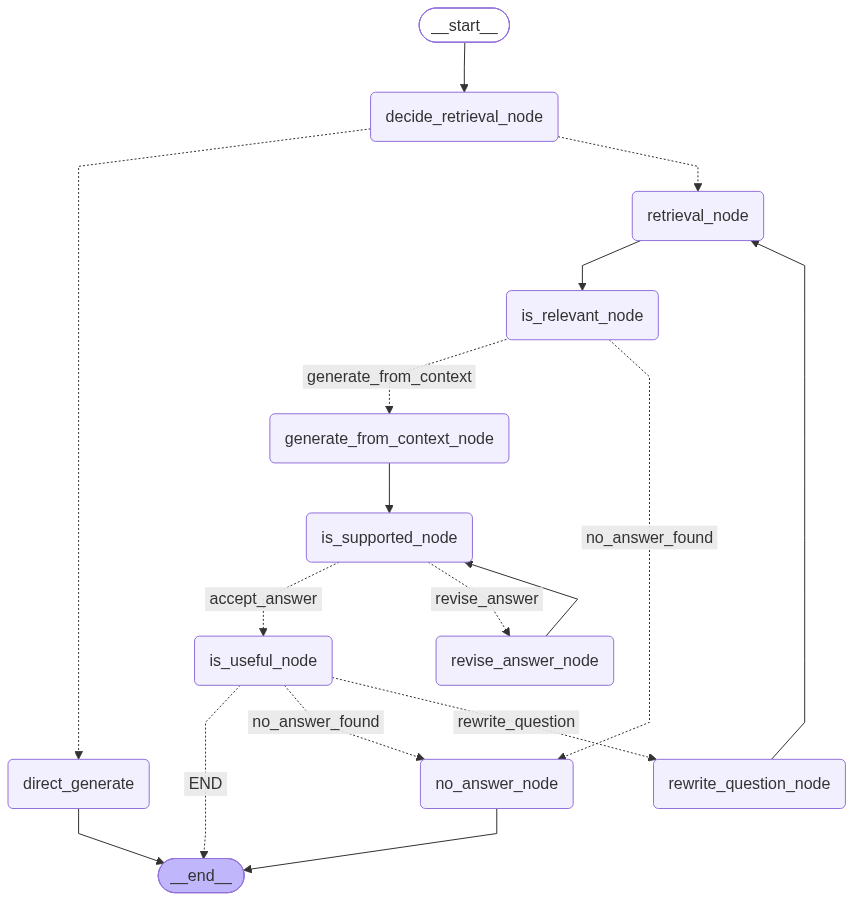

In [179]:
self_rag

In [ ]:
initial_state = {
    "question": "Describe NexaAI’s company culture.",
    "retrieval_query": "",
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}

In [ ]:
result = self_rag.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

In [ ]:
result

{'question': 'Describe NexaAI’s company culture.',
 'retrieval_query': 'NexaAI company culture values mission vision',
 'rewrite_tries': 1,
 'need_retrieval': True,
 'docs': [Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '/home/jiggra/Self_RAG/documents/Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', '_id': '64ba899aca114816af98414338cc9f5c', '_collection_name': 'self_rag'}, page_content='NexaAI Solutions – Company Profile\nCompany Overview\nNexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.\nThe company specializes in building enterprise-ready AI systems for knowledge management,\nanalytics, and automation.\nNexaAI primarily serves mid-sized and large org